--- Loading Data: data/Electric_Vehicle_Population_Data.csv ---

--- Training Elastic Net (Tuning Hyperparameters) ---
Best Alpha: 0.01
Best L1 Ratio: 1.0
R-squared: 0.9297
MAE: 17.70 miles

--- Top 5 Positive Drivers of Range ---
Electric Vehicle Type_Battery Electric Vehicle (BEV)    166.739807
Make_TESLA                                               69.174146
Make_CHEVROLET                                           60.554258
Make_JAGUAR                                              44.112813
Make_POLESTAR                                            39.369459
dtype: float64

--- Top 5 Features Zeroed Out by Lasso Penalty ---
Make_KIA                    -0.0
Make_SUBARU                  0.0
Make_ALFA ROMEO             -0.0
Make_AZURE DYNAMICS         -0.0
Make_WHEEGO ELECTRIC CARS    0.0
dtype: float64


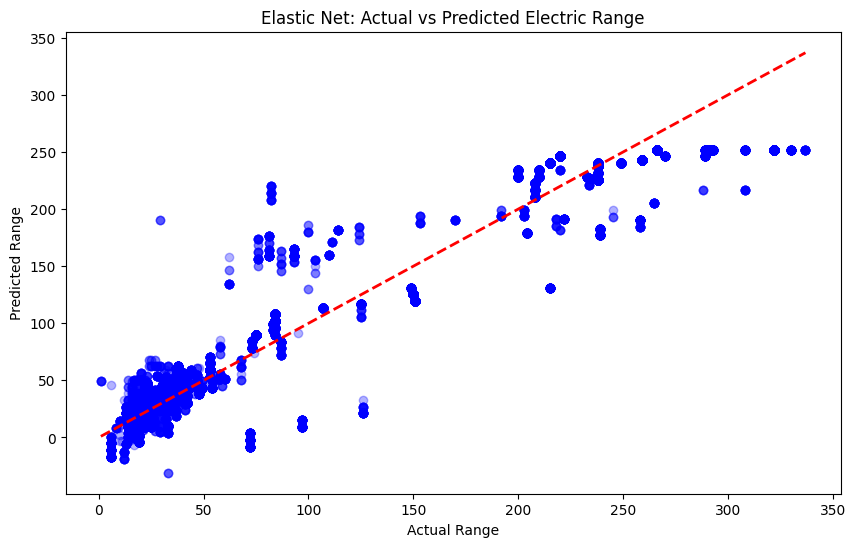

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

def run_elastic_net_workshop(csv_path):
    # 1. Load and Clean Data
    print(f"--- Loading Data: {csv_path} ---")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print("Error: CSV not found. Please download from Data.gov.")
        return

    # Define target and features
    target = 'Electric Range'
    features = [
        'Model Year', 
        'Make', 
        'Electric Vehicle Type', 
        'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
    ]

    # Filter for usable range data (>0)
    df_clean = df[df[target] > 0].copy()
    
    X = df_clean[features]
    y = df_clean[target]

    # 2. Build Preprocessing Pipeline
    # Elastic Net is sensitive to scale, so we MUST use StandardScaler
    numeric_features = ['Model Year']
    categorical_features = ['Make', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])

    # 3. Prepare Training/Testing Sets
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Apply preprocessing
    X_train = preprocessor.fit_transform(X_train_raw)
    X_test = preprocessor.transform(X_test_raw)

    # 4. Train Elastic Net with Cross-Validation
    # ElasticNetCV automatically tunes 'alpha' (strength) and 'l1_ratio' (mix of Lasso/Ridge)
    print("\n--- Training Elastic Net (Tuning Hyperparameters) ---")
    model = ElasticNetCV(
        l1_ratio=[.1, .5, .7, .9, .95, .99, 1], # Mix ratio: 1 is Lasso, 0 is Ridge
        alphas=[0.01, 0.1, 1.0, 10.0],
        cv=5,
        random_state=42,
        max_iter=5000
    )
    
    model.fit(X_train, y_train)

    # 5. Evaluation
    y_pred = model.predict(X_test)
    
    print(f"Best Alpha: {model.alpha_}")
    print(f"Best L1 Ratio: {model.l1_ratio_}")
    print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} miles")

    # 6. Interpretability (Feature Importance)
    # Get feature names after One-Hot Encoding
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_feature_names = numeric_features + list(cat_feature_names)
    
    # Map coefficients to names
    coef_map = pd.Series(model.coef_, index=all_feature_names).sort_values(ascending=False)

    print("\n--- Top 5 Positive Drivers of Range ---")
    print(coef_map.head(5))

    print("\n--- Top 5 Features Zeroed Out by Lasso Penalty ---")
    zeroed = coef_map[coef_map == 0]
    print(zeroed.head(5) if not zeroed.empty else "No features zeroed out.")

    # 7. Visualization: Predicted vs Actual
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    plt.xlabel('Actual Range')
    plt.ylabel('Predicted Range')
    plt.title('Elastic Net: Actual vs Predicted Electric Range')
    plt.show()

if __name__ == "__main__":
    FILE_PATH = 'data/Electric_Vehicle_Population_Data.csv'
    run_elastic_net_workshop(FILE_PATH)